In [38]:
from fredapi import Fred
import yfinance as yf
from fred_api_key import API_KEY
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume,Asset_Returns,FedFunds,Inflation,Strategy,Strategy_Returns
1993-02-02,24.537838,44.343750,44.375000,44.125000,44.218750,201300.0,0.009246,3.18,3.24675,-1,-0.002119
1993-02-03,24.797224,44.812500,44.843750,44.375000,44.406250,529400.0,0.019915,3.56,3.24675,1,0.008430
1993-02-04,24.900988,45.000000,45.093750,44.468750,44.968750,531500.0,0.024182,3.08,3.24675,-1,0.004210
1993-02-05,24.883690,44.968750,45.062500,44.718750,44.968750,492100.0,0.023471,2.87,3.24675,-1,0.004908
1993-02-06,24.883690,44.968750,45.062500,44.718750,44.968750,492100.0,0.023471,2.87,3.24675,-1,0.004908
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-17,664.390015,664.390015,665.760010,658.140015,659.500000,96500900.0,14.121252,4.11,2.93922,1,0.208869
2025-10-18,664.390015,664.390015,665.760010,658.140015,659.500000,96500900.0,14.121252,4.11,2.93922,1,0.208869
2025-10-19,664.390015,664.390015,665.760010,658.140015,659.500000,96500900.0,14.121252,4.11,2.93922,1,0.208869
2025-10-20,671.299988,671.299988,672.210022,667.270020,667.320007,60493400.0,14.278520,4.11,2.93922,1,0.221442


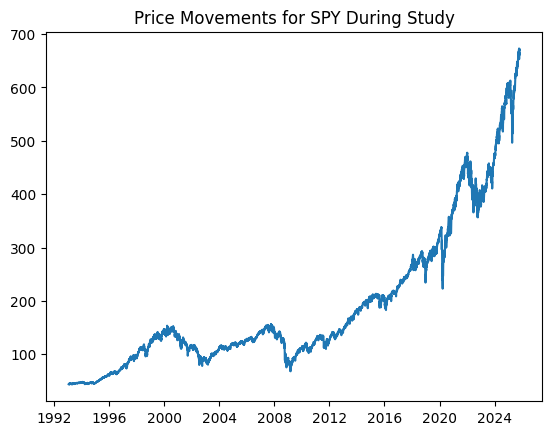

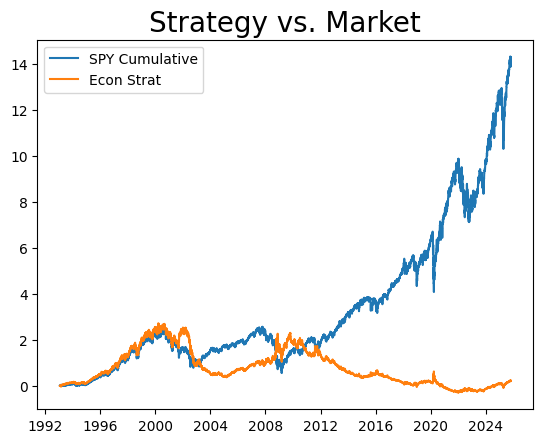

In [39]:
TICKER = 'SPY'
INTERVAL = '1d'
PERIOD = '730d' if INTERVAL == '1h' else 'max'

LOOKBACK = 10000
fred = Fred(api_key=API_KEY)

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    df = yf.download(ticker, interval=interval, auto_adjust=False, period=PERIOD, group_by='column')
    df.columns = df.columns.get_level_values(0)

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1

    # only return the subset of data you are interested in
    subset = df.iloc[-lookback:, :]
    plt.figure()
    plt.plot(subset['Close'])
    plt.title(f'Price Movements for {ticker} During Study')

    return subset.dropna()

def add_interest_rates(df):
    fedfunds = pd.DataFrame(fred.get_series('DFF'), columns=['FedFunds'])
    combined = pd.concat([df, fedfunds], axis=1) 
    return combined

def add_inflation(df):
    inflation = pd.DataFrame(fred.get_series('CPIAUCSL', units='pc1'), columns=['Inflation'])
    combined = pd.concat([df, inflation], axis=1).ffill() 
    return combined

def add_economic_strategy(df):
    df['Strategy'] = np.where(df['Inflation'] > df['FedFunds'], -1, 1)
    return df

def test_strategy(df):

    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Econ Strat'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_interest_rates(df)
    df = add_inflation(df)
    df = add_economic_strategy(df)
    df = test_strategy(df)
    return df

df = main()
df = df.dropna()

df

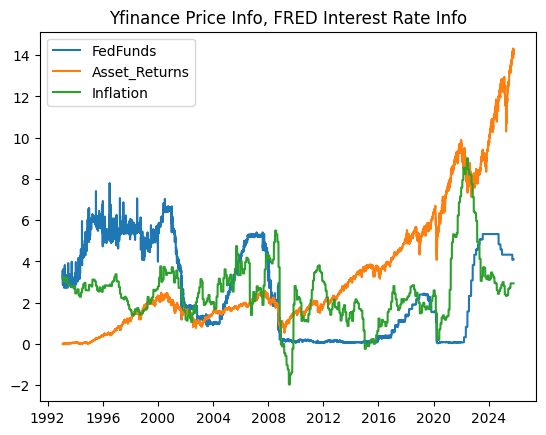

In [43]:
plt.plot(df['FedFunds'])
plt.plot(df['Asset_Returns'])
plt.plot(df['Inflation'])
plt.legend(['FedFunds', 'Asset_Returns', 'Inflation'])
plt.title('Yfinance Price Info, FRED Interest Rate Info');